In [1]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

In [3]:


df = pd.read_csv('./Downloads/games.csv')



df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']



In [4]:
df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        122610 non-null  object 
 1   Release date                122611 non-null  object 
 2   Estimated owners            122611 non-null  object 
 3   Peak CCU                    122611 non-null  int64  
 4   Required age                122611 non-null  int64  
 5   Price                       122611 non-null  float64
 6   Discount                    122611 non-null  int64  
 7   DLC count                   122611 non-null  int64  
 8   About the game              114162 non-null  object 
 9   Supported languages         122611 non-null  object 
 10  Full audio languages        122611 non-null  object 
 11  Reviews                     12070 non-null   object 
 12  Header image                122530 non-null  object 
 13  Website     

In [6]:
df_filtered = df[df["Notes"].notna()]
print(df_filtered["Notes"])

3292190    The game includes the following elements. 1. G...
1654170    The trailer and the screenshots may contain co...
2922740                                           gore,blood
1282900    Game contains nudity, uncensored genitalia and...
2403000    The game contains Nudity or Sexual Content, Al...
                                 ...                        
4204040                     - Nudity - Strong sexual content
4249780    Violence is present through the act of killing...
4182060    Blood will appear when enemies or zombies are ...
4153410    All characters depicted in this game are 18 ye...
4042800    During poker gameplay, if a player loses all t...
Name: Notes, Length: 22458, dtype: object


In [7]:
inutiles = ["About the game", "Reviews", "Website", "Support url", "Support email", 
            "Metacritic url", "Notes", "Score rank", "Movies", "Header image", "Screenshots"]
df2 = df.drop(columns=inutiles)
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        122610 non-null  object 
 1   Release date                122611 non-null  object 
 2   Estimated owners            122611 non-null  object 
 3   Peak CCU                    122611 non-null  int64  
 4   Required age                122611 non-null  int64  
 5   Price                       122611 non-null  float64
 6   Discount                    122611 non-null  int64  
 7   DLC count                   122611 non-null  int64  
 8   Supported languages         122611 non-null  object 
 9   Full audio languages        122611 non-null  object 
 10  Windows                     122611 non-null  bool   
 11  Mac                         122611 non-null  bool   
 12  Linux                       122611 non-null  bool   
 13  Metacritic s

In [8]:
# 1. Fonction pour fusionner, nettoyer les espaces et dédoublonner chaque ligne
def merge_and_clean(row):
    # Séparer les mots par la virgule et gérer les cas où la cellule est vide (NaN)
    tags = str(row['Tags']).split(',') if pd.notna(row['Tags']) else[]
    genres = str(row['Genres']).split(',') if pd.notna(row['Genres']) else[]
    
    # Fusionner les deux listes, enlever les espaces (strip) et garder uniquement les valeurs non-vides
    tous_les_mots =[mot.strip() for mot in (tags + genres) if mot.strip()]
    
    # Utiliser set() pour supprimer les doublons (ex: si 'Action' est à la fois dans Tags et Genre)
    mots_uniques = set(tous_les_mots)
    
    # Rejoindre sous forme de chaîne de caractères séparée par des virgules
    return ','.join(mots_uniques)

# 2. Appliquer la fonction pour créer une colonne combinée temporaire
combined_series = df2.apply(merge_and_clean, axis=1)

# 3. Séparer en colonnes (One-Hot Encoding)
combined_dummies = combined_series.str.get_dummies(sep=',')

# 4. Renommer les colonnes avec un préfixe propre
combined_dummies.columns =[f"TagGenre_{c}" for c in combined_dummies.columns]

# 5. Concaténer le résultat avec le DataFrame d'origine
df2 = pd.concat([df2, combined_dummies], axis=1)

# Afficher le résultat pour vérifier
print(df2.head())

                                          Name  Release date Estimated owners  \
2539430             Black Dragon Mage Playtest   Aug 1, 2023            0 - 0   
496350   Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016        0 - 20000   
1034400      Mystery Solitaire The Black Raven   May 6, 2019        0 - 20000   
3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024        0 - 20000   
3631080                          Maze Quest VR  Apr 24, 2025        0 - 20000   

         Peak CCU  Required age  Price  Discount  DLC count  \
2539430         0             0   0.00         0          0   
496350          0             0   5.24        65          0   
1034400         0             0   4.99         0          0   
3292190         1             0   8.99         0          1   
3631080         0             0   4.99         0          0   

                                Supported languages Full audio languages  ...  \
2539430                                          []  

In [9]:
Optionels = ["Developers", "Publishers"]
df3 = df2.drop(columns=Optionels)
df3.info(verbose=all)

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 480 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    Name                                        object 
 1    Release date                                object 
 2    Estimated owners                            object 
 3    Peak CCU                                    int64  
 4    Required age                                int64  
 5    Price                                       float64
 6    Discount                                    int64  
 7    DLC count                                   int64  
 8    Supported languages                         object 
 9    Full audio languages                        object 
 10   Windows                                     bool   
 11   Mac                                         bool   
 12   Linux                                       bool   
 13   Metacritic

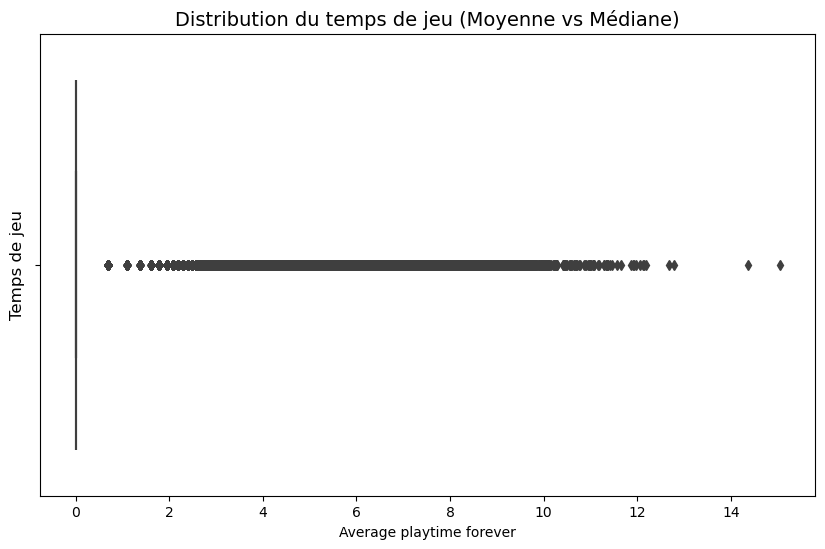

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définir la taille du graphique pour qu'il soit bien lisible
plt.figure(figsize=(10, 6))

# 2. Créer le boxplot avec Seaborn
# On sélectionne uniquement les deux colonnes qui nous intéressent
sns.boxplot(
    x=np.log(df2['Average playtime forever']+1), 
)

# 3. Ajouter des titres et labels pour faire propre
plt.title("Distribution du temps de jeu (Moyenne vs Médiane)", fontsize=14)
plt.ylabel("Temps de jeu", fontsize=12)


# 4. Afficher le graphique
plt.show()

In [11]:
np.sum(df["Recommendations"] != 0)

20906

In [12]:
col = "Required age"
df_filtered = df[df[col] != 0]
print(df_filtered[col].value_counts())

Required age
17    828
13    175
18    164
16     32
10     26
12     23
3       6
7       5
6       4
15      3
1       2
21      2
14      1
20      1
Name: count, dtype: int64


In [13]:
for col in df2.columns :
    print(f"La colonne {col} à {len(pd.unique(df2[col]))} modalites")

La colonne Name à 121455 modalites
La colonne Release date à 5081 modalites
La colonne Estimated owners à 14 modalites
La colonne Peak CCU à 1110 modalites
La colonne Required age à 15 modalites
La colonne Price à 941 modalites
La colonne Discount à 88 modalites
La colonne DLC count à 117 modalites
La colonne Supported languages à 19113 modalites
La colonne Full audio languages à 3710 modalites
La colonne Windows à 2 modalites
La colonne Mac à 2 modalites
La colonne Linux à 2 modalites
La colonne Metacritic score à 73 modalites
La colonne User score à 31 modalites
La colonne Positive à 5540 modalites
La colonne Negative à 2725 modalites
La colonne Achievements à 448 modalites
La colonne Recommendations à 5332 modalites
La colonne Average playtime forever à 3037 modalites
La colonne Average playtime two weeks à 993 modalites
La colonne Median playtime forever à 2511 modalites
La colonne Median playtime two weeks à 993 modalites
La colonne Developers à 70813 modalites
La colonne Publishe

In [14]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Columns: 482 entries, Name to TagGenre_e-sports
dtypes: bool(3), float64(1), int64(468), object(10)
memory usage: 449.4+ MB


In [15]:
df2["Negative"]

2539430    0
496350     3
1034400    3
3292190    0
3631080    0
          ..
4152910    0
4042800    0
3522550    0
3680350    0
4141790    0
Name: Negative, Length: 122611, dtype: int64

In [16]:
bool_cols = ["Windows", "Mac", "Linux"]
df2[bool_cols] = df2[bool_cols].astype(bool)

In [17]:
Categories_dummies = df2['Categories'].str.get_dummies(sep=',')
Categories_dummies.columns = [f"Categories_{c.strip()}" for c in Categories_dummies.columns] # merci gemini
Categories_dummies
# df2 = pd.concat([df2, genres_dummies], axis=1)

,Categories_Adjustable Difficulty,Categories_Adjustable Text Size,Categories_Camera Comfort,Categories_Captions available,Categories_Chat Speech-to-text,Categories_Chat Text-to-speech,Categories_Co-op,Categories_Color Alternatives,Categories_Commentary available,Categories_Cross-Platform Multiplayer,...,Categories_SteamVR Collectibles,Categories_Stereo Sound,Categories_Subtitle Options,Categories_Surround Sound,Categories_Touch Only Option,Categories_Tracked Controller Support,Categories_VR Only,Categories_VR Support,Categories_VR Supported,Categories_Valve Anti-Cheat enabled
2539430,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1034400,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3292190,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3631080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4042800,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3522550,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3680350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
genres_dummies = df2['Genres'].str.get_dummies(sep=',')
genres_dummies.columns = [f"Genre_{c.strip()}" for c in genres_dummies.columns] # merci gemini
genres_dummies
# df2 = pd.concat([df2, genres_dummies], axis=1)

,Genre_360 Video,Genre_Accounting,Genre_Action,Genre_Adventure,Genre_Animation & Modeling,Genre_Audio Production,Genre_Casual,Genre_Design & Illustration,Genre_Documentary,Genre_Early Access,...,Genre_Short,Genre_Simulation,Genre_Software Training,Genre_Sports,Genre_Strategy,Genre_Tutorial,Genre_Utilities,Genre_Video Production,Genre_Violent,Genre_Web Publishing
2539430,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496350,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1034400,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3292190,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3631080,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,0,0,1,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4042800,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3522550,0,0,1,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3680350,0,0,1,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
import matplotlib.pyplot as plt

# Sélection des colonnes numériques
numeric_cols = df2.select_dtypes(include=['int64', 'float64']).columns

n_cols = len(numeric_cols)
fig, axes = plt.subplots(n_cols, 1, figsize=(10, 3 * n_cols))

for i, col in enumerate(numeric_cols):
    # On crée une série filtrée qui exclut les 0
    data_to_plot = df2[df2[col] != 0][col]
    
    # On trace l'histogramme uniquement avec les données non nulles
    data_to_plot.hist(ax=axes[i], bins=50, edgecolor='black', grid=False)
    axes[i].set_yscale('log', base=2)
    axes[i].set_title(f'Distribution de {col} (hors zéros)')
    axes[i].set_ylabel('Fréquence')
    print(f"Graph de {col} Fait")

plt.tight_layout()
plt.show()

Graph de Peak CCU Fait
Graph de Required age Fait
Graph de Price Fait
Graph de Discount Fait
Graph de DLC count Fait
Graph de Metacritic score Fait
Graph de User score Fait
Graph de Positive Fait
Graph de Negative Fait
Graph de Achievements Fait
Graph de Recommendations Fait
Graph de Average playtime forever Fait
Graph de Average playtime two weeks Fait
Graph de Median playtime forever Fait
Graph de Median playtime two weeks Fait
Graph de TagGenre_1980s Fait
Graph de TagGenre_1990's Fait
Graph de TagGenre_2.5D Fait
Graph de TagGenre_2D Fait
Graph de TagGenre_2D Fighter Fait
Graph de TagGenre_2D Platformer Fait
Graph de TagGenre_360 Video Fait
Graph de TagGenre_3D Fait
Graph de TagGenre_3D Fighter Fait
Graph de TagGenre_3D Platformer Fait
Graph de TagGenre_3D Vision Fait
Graph de TagGenre_4 Player Local Fait
Graph de TagGenre_4X Fait
Graph de TagGenre_6DOF Fait
Graph de TagGenre_8-bit Music Fait
Graph de TagGenre_ATV Fait
Graph de TagGenre_Abstract Fait
Graph de TagGenre_Accounting Fait

ValueError: Image size of 1000x140700 pixels is too large. It must be less than 2^16 in each direction.

Error in callback <function _draw_all_if_interactive at 0x7f29b4cad4e0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Image size of 1000x140700 pixels is too large. It must be less than 2^16 in each direction.

ValueError: Image size of 1000x140700 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1000x140700 with 469 Axes>

In [20]:
df2[(df2["Positive"]>1000000)]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,TagGenre_Well-Written,TagGenre_Werewolves,TagGenre_Western,TagGenre_Wholesome,TagGenre_Word Game,TagGenre_World War I,TagGenre_World War II,TagGenre_Wrestling,TagGenre_Zombies,TagGenre_e-sports
570,Dota 2,"Jul 9, 2013",100000000 - 200000000,623941,0,0.00,0,2,"['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...","['English', 'Korean', 'Simplified Chinese', 'V...",...,0,0,0,0,0,0,0,0,0,1
252490,Rust,"Feb 8, 2018",20000000 - 50000000,143870,0,19.99,50,5,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,0,0,0,0,0,0,0
578080,PUBG: BATTLEGROUNDS,"Dec 21, 2017",100000000 - 200000000,314682,13,0.00,0,0,"['English', 'Korean', 'Simplified Chinese', 'F...",[],...,0,0,0,0,0,0,0,0,0,0
105600,Terraria,"May 16, 2011",20000000 - 50000000,24580,0,4.99,50,2,"['English', 'French', 'Italian', 'German', 'Sp...",[],...,0,0,0,0,0,0,0,0,0,0
4000,Garry's Mod,"Nov 29, 2006",20000000 - 50000000,18400,0,4.99,50,0,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Slovak']",...,0,0,0,0,0,0,0,0,0,0
359550,Tom Clancy's Rainbow Six® Siege X,"Dec 1, 2015",20000000 - 50000000,51847,17,0.00,0,9,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,0,0,0,0,0,0,1
2358720,Black Myth: Wukong,"Aug 19, 2024",50000000 - 100000000,15004,13,59.99,0,2,"['English', 'French', 'German', 'Spanish - Spa...","['English', 'Simplified Chinese', 'Czech']",...,0,0,0,0,0,0,0,0,0,0
730,Counter-Strike 2,"Aug 21, 2012",100000000 - 200000000,1013936,0,0.00,0,1,"['Czech', 'Danish', 'Dutch', 'English', 'Finni...","['English', 'Indonesian']",...,0,0,0,0,0,0,0,0,0,1
440,Team Fortress 2,"Oct 10, 2007",50000000 - 100000000,43819,0,0.00,0,1,"['English', 'Danish', 'Dutch', 'Finnish', 'Fre...","['English', 'Spanish - Latin America']",...,0,0,0,0,0,0,0,0,0,0
271590,Grand Theft Auto V Legacy,"Apr 13, 2015",50000000 - 100000000,67851,17,0.00,0,0,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Spanish - Latin America']",...,0,0,0,0,0,0,0,0,0,0


In [21]:
np.unique(df2["Estimated owners"])

array(['0 - 0', '0 - 20000', '100000 - 200000', '1000000 - 2000000',
       '10000000 - 20000000', '100000000 - 200000000', '20000 - 50000',
       '200000 - 500000', '2000000 - 5000000', '20000000 - 50000000',
       '50000 - 100000', '500000 - 1000000', '5000000 - 10000000',
       '50000000 - 100000000'], dtype=object)

In [22]:
df2[df2["Peak CCU"]==0]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,TagGenre_Well-Written,TagGenre_Werewolves,TagGenre_Western,TagGenre_Wholesome,TagGenre_Word Game,TagGenre_World War I,TagGenre_World War II,TagGenre_Wrestling,TagGenre_Zombies,TagGenre_e-sports
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],...,0,0,0,0,0,0,0,0,0,0
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],...,0,0,0,0,0,0,0,0,0,0
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],...,0,0,0,0,0,0,0,0,0,0
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],...,0,0,0,0,0,0,0,0,0,0
1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Turkish']",...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,完美传奇,"Jan 4, 2026",0 - 0,0,0,0.00,0,0,"['Simplified Chinese', 'Traditional Chinese']","['Simplified Chinese', 'Traditional Chinese']",...,0,0,0,0,0,0,0,0,0,0
4042800,Poker Fate - ACG Texas Hold'em,"Jan 3, 2026",0 - 0,0,0,0.00,0,0,"['English', 'Japanese', 'Simplified Chinese', ...","['Japanese', 'Traditional Chinese']",...,0,0,0,0,0,0,0,0,0,0
3522550,Adira Nusantara,"Jan 3, 2026",0 - 0,0,0,7.99,0,0,['English'],['English'],...,0,0,0,0,0,0,0,0,0,0
3680350,A Lenda de Niterói,"Jan 4, 2026",0 - 0,0,0,2.09,0,0,"['Portuguese - Brazil', 'English']","['Portuguese - Brazil', 'English']",...,0,0,0,0,0,0,0,0,0,0


In [23]:
df2[df2["Positive"]==0][df2["Negative"]==0][df2["Recommendations"]==0]

/tmp/ipykernel_11075/1242817248.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2[df2["Positive"]==0][df2["Negative"]==0][df2["Recommendations"]==0]
/tmp/ipykernel_11075/1242817248.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2[df2["Positive"]==0][df2["Negative"]==0][df2["Recommendations"]==0]


,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,TagGenre_Well-Written,TagGenre_Werewolves,TagGenre_Western,TagGenre_Wholesome,TagGenre_Word Game,TagGenre_World War I,TagGenre_World War II,TagGenre_Wrestling,TagGenre_Zombies,TagGenre_e-sports
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],...,0,0,0,0,0,0,0,0,0,0
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],...,0,0,0,0,0,0,0,0,0,0
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],...,0,0,0,0,0,0,0,0,0,0
1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Turkish']",...,0,0,0,0,0,0,0,0,0,0
700340,Galacatraz: Eject Equip Escape,"Feb 1, 2018",0 - 20000,0,0,0.99,0,0,['English'],['English'],...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,完美传奇,"Jan 4, 2026",0 - 0,0,0,0.00,0,0,"['Simplified Chinese', 'Traditional Chinese']","['Simplified Chinese', 'Traditional Chinese']",...,0,0,0,0,0,0,0,0,0,0
4042800,Poker Fate - ACG Texas Hold'em,"Jan 3, 2026",0 - 0,0,0,0.00,0,0,"['English', 'Japanese', 'Simplified Chinese', ...","['Japanese', 'Traditional Chinese']",...,0,0,0,0,0,0,0,0,0,0
3522550,Adira Nusantara,"Jan 3, 2026",0 - 0,0,0,7.99,0,0,['English'],['English'],...,0,0,0,0,0,0,0,0,0,0
3680350,A Lenda de Niterói,"Jan 4, 2026",0 - 0,0,0,2.09,0,0,"['Portuguese - Brazil', 'English']","['Portuguese - Brazil', 'English']",...,0,0,0,0,0,0,0,0,0,0


In [24]:
df2[df2['Tags'].isnull() == False]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,TagGenre_Well-Written,TagGenre_Werewolves,TagGenre_Western,TagGenre_Wholesome,TagGenre_Word Game,TagGenre_World War I,TagGenre_World War II,TagGenre_Wrestling,TagGenre_Zombies,TagGenre_e-sports
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],...,0,0,0,0,0,0,0,0,0,0
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],...,0,0,0,0,0,0,0,0,0,0
1934300,Armored Brigade II,"Apr 8, 2025",0 - 20000,8,0,35.99,10,1,['English'],[],...,0,0,0,0,0,0,0,0,0,0
1157670,Hepta Beats,"May 7, 2021",0 - 20000,0,0,0.99,0,0,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,0,0,0,0,0,0,0
1540330,MUMBA IV: Egypt Jewels,"Dec 13, 2021",0 - 20000,1,0,0.59,0,1,"['English', 'French', 'Italian', 'German', 'Sp...",[],...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580300,Super Stone Legacy,"May 26, 2017",0 - 20000,0,0,7.99,0,0,['English'],[],...,0,0,0,0,0,0,0,0,0,0
372950,Professor Why™ Chemistry 1,"Oct 14, 2015",0 - 20000,0,0,9.99,0,0,"['English', 'Polish']","['English', 'Polish']",...,0,0,0,0,0,0,0,0,0,0
2741620,Exiled,"Jan 18, 2024",20000 - 50000,0,0,2.49,50,0,['English'],['English'],...,0,0,0,0,0,0,0,0,0,0
2447310,Knight Overloaded,"Jun 15, 2023",20000 - 50000,0,0,0.00,0,0,"['English', 'Korean']",[],...,0,0,0,0,0,0,0,0,0,0


In [25]:
Tags_dummies = df2['Tags'].str.get_dummies(sep=',')
Tags_dummies.columns = [f"Tags_{c.strip()}" for c in Tags_dummies.columns] # merci gemini
Tags_dummies
# df2 = pd.concat([df2, genres_dummies], axis=1)

,Tags_1980s,Tags_1990's,Tags_2.5D,Tags_2D,Tags_2D Fighter,Tags_2D Platformer,Tags_360 Video,Tags_3D,Tags_3D Fighter,Tags_3D Platformer,...,Tags_Well-Written,Tags_Werewolves,Tags_Western,Tags_Wholesome,Tags_Word Game,Tags_World War I,Tags_World War II,Tags_Wrestling,Tags_Zombies,Tags_e-sports
2539430,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1034400,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3292190,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3631080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4042800,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3522550,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3680350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
(df2[df2["Price"] > 500])

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,TagGenre_Well-Written,TagGenre_Werewolves,TagGenre_Western,TagGenre_Wholesome,TagGenre_Word Game,TagGenre_World War I,TagGenre_World War II,TagGenre_Wrestling,TagGenre_Zombies,TagGenre_e-sports
1200520,Ascent Free-Roaming VR Experience,"Dec 27, 2019",0 - 20000,0,0,999.00,0,0,['English'],['English'],...,0,0,0,0,0,0,0,0,1,0
2504210,The Leverage Game Business Edition,"Aug 26, 2023",0 - 20000,0,0,999.98,0,0,"['English', 'Japanese']","['English', 'Japanese']",...,0,0,0,0,0,0,0,0,0,0
2499620,The Leverage Game,"Aug 25, 2023",0 - 20000,0,0,999.98,0,0,"['English', 'Japanese']","['English', 'Japanese']",...,0,0,0,0,0,0,0,0,0,0


In [27]:
df2[df2["Name"]=="Ascent Free-Roaming VR Experience"]["Positive"]

1200520    6
Name: Positive, dtype: int64

In [28]:
df2[df2["DLC count"]>200]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,TagGenre_Well-Written,TagGenre_Werewolves,TagGenre_Western,TagGenre_Wholesome,TagGenre_Word Game,TagGenre_World War I,TagGenre_World War II,TagGenre_Wrestling,TagGenre_Zombies,TagGenre_e-sports
220700,RPG Maker VX Ace,"Dec 10, 2012",100000 - 200000,225,0,6.99,0,448,"['English', 'French', 'German', 'Spanish - Spa...",[],...,0,0,0,0,0,0,0,0,0,0
1096900,RPG Maker MZ,"Aug 27, 2020",200000 - 500000,783,0,35.99,0,875,"['English', 'Japanese', 'French', 'Italian', '...",[],...,0,0,0,0,0,0,0,0,0,0
1333350,Angel Legion,"Aug 14, 2020",500000 - 1000000,450,0,0.00,0,314,"['English', 'Simplified Chinese', 'Traditional...","['Simplified Chinese', 'Traditional Chinese', ...",...,0,0,0,0,0,0,0,0,0,0
24049,Train Simulator Classic,"Sep 17, 2015",0 - 20000,0,0,22.49,25,782,"['English', 'French', 'Italian', 'German', 'Sp...",[],...,0,0,0,0,0,0,0,0,0,0
314160,Microsoft Flight Simulator X: Steam Edition,"Dec 18, 2014",2000000 - 5000000,486,0,4.99,80,234,['English'],[],...,0,0,0,0,0,0,0,0,0,0
24058,Train Simulator Classic,"Sep 17, 2015",0 - 20000,0,0,22.49,0,782,"['English', 'French', 'Italian', 'German', 'Sp...",[],...,0,0,0,0,0,0,0,0,0,0
553520,Trainz Railroad Simulator 2019,"Jan 7, 2019",50000 - 100000,195,0,7.99,80,272,"['English', 'French', 'Italian', 'German', 'Sp...",[],...,0,0,0,0,0,0,0,0,0,0
620980,Beat Saber,"May 21, 2019",2000000 - 5000000,423,0,29.99,0,261,"['English', 'French', 'German', 'Spanish - Spa...","['English', 'French', 'German', 'Spanish - Spa...",...,0,0,0,0,0,0,0,0,0,0
252690,Fantasy Grounds Classic,"May 9, 2014",100000 - 200000,1,0,0.00,0,2006,['English'],[],...,0,0,0,0,0,0,0,0,0,0
221680,Rocksmith® 2014 Edition REMASTERED LEARN & PLAY,"Dec 19, 2024",500000 - 1000000,683,0,9.99,0,967,"['English', 'German', 'French', 'Italian', 'Sp...","['English', 'German', 'French', 'Italian', 'Sp...",...,0,0,0,0,0,0,0,0,0,0


In [29]:
len(df3["Name"].unique())

121455

In [30]:
len(df3["Name"])

122611

In [31]:
# 1. Tu récupères le compte de chaque nom
comptes = df3["Name"].value_counts()

# 2. Tu gardes uniquement les noms qui apparaissent plus d'une fois (> 1)
noms_en_double = comptes[comptes > 1].index

# 3. Tu filtres ton dataframe pour n'afficher QUE les jeux dont le nom est dans cette liste
lignes_a_comparer = df3[df3["Name"].isin(noms_en_double)]

# 4. Tu tries par nom pour pouvoir comparer visuellement l'individu A et l'individu B
lignes_a_comparer = lignes_a_comparer.sort_values(by="Name")

# Affichage
display(lignes_a_comparer[lignes_a_comparer["Peak CCU"]== 0])

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,TagGenre_Well-Written,TagGenre_Werewolves,TagGenre_Western,TagGenre_Wholesome,TagGenre_Word Game,TagGenre_World War I,TagGenre_World War II,TagGenre_Wrestling,TagGenre_Zombies,TagGenre_e-sports
3763930,A Better Tomorrow,"Sep 30, 2025",0 - 0,0,0,0.00,0,0,['Simplified Chinese'],[],...,0,0,0,0,0,0,0,0,0,0
3022780,A Better Tomorrow,"Jul 31, 2024",0 - 20000,0,0,0.00,0,0,"['English', 'Spanish - Spain']",[],...,0,0,0,0,0,0,0,0,0,0
557900,A Walk in the Woods,"Apr 21, 2020",0 - 20000,0,0,0.00,0,0,['English'],[],...,0,0,0,0,0,0,0,0,0,0
842420,A Walk in the Woods,"May 1, 2018",100000 - 200000,0,0,0.00,0,0,['English'],['English'],...,0,0,0,0,0,0,0,0,0,0
1826070,ALONE,"Dec 23, 2021",0 - 20000,0,0,8.99,0,0,['English'],['English'],...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2369750,垃圾游戏,"Jun 11, 2023",0 - 20000,0,0,2.99,0,0,['Simplified Chinese'],['Simplified Chinese'],...,0,0,0,0,0,0,0,0,0,0
1350860,归途,"Jul 12, 2020",0 - 20000,0,0,74.99,0,0,['Simplified Chinese'],[],...,0,0,0,0,0,0,0,0,0,0
3751690,归途,"Jun 13, 2025",0 - 20000,0,0,0.79,0,0,['Simplified Chinese'],[],...,0,0,0,0,0,0,0,0,0,0
2076350,蜀山：初章 Playtest,"Jul 6, 2022",0 - 0,0,0,0.00,0,0,[],[],...,0,0,0,0,0,0,0,0,0,0


In [32]:
lignes_a_comparer[lignes_a_comparer["Peak CCU"] == max(lignes_a_comparer["Peak CCU"])]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,TagGenre_Well-Written,TagGenre_Werewolves,TagGenre_Western,TagGenre_Wholesome,TagGenre_Word Game,TagGenre_World War I,TagGenre_World War II,TagGenre_Wrestling,TagGenre_Zombies,TagGenre_e-sports
359550,Tom Clancy's Rainbow Six® Siege X,"Dec 1, 2015",20000000 - 50000000,51847,17,0.0,0,9,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'French', 'Italian', 'German', 'Sp...",...,0,0,0,0,0,0,0,0,0,1


In [33]:
lignes_a_comparer[lignes_a_comparer["Name"] == "A Walk in the Woods"]

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,TagGenre_Well-Written,TagGenre_Werewolves,TagGenre_Western,TagGenre_Wholesome,TagGenre_Word Game,TagGenre_World War I,TagGenre_World War II,TagGenre_Wrestling,TagGenre_Zombies,TagGenre_e-sports
557900,A Walk in the Woods,"Apr 21, 2020",0 - 20000,0,0,0.0,0,0,['English'],[],...,0,0,0,0,0,0,0,0,0,0
842420,A Walk in the Woods,"May 1, 2018",100000 - 200000,0,0,0.0,0,0,['English'],['English'],...,0,0,0,0,0,0,0,0,0,0
